# Image segmentation of scanned documents using K-Means clustering.

This module applies unsupervised K-Means clustering (k=3) to partition a
scanned document image into three semantic regions:

1. **Foreground** - dark ink / handwritten text pixels.
2. **Background** - bright page colour (white, cream, or yellowed paper).
3. **Noise** - intermediate-brightness artefacts such as shadows, scanner noise, coffee stains, and image compression artefacts (e.g. JPEG blocking).


In [65]:
from typing import Tuple

# -------------------------------------------------------------------------
# Constants
# -------------------------------------------------------------------------
UPLOADS_DIR = "../uploads"

# Default number of K-Means clusters.
# Matches the three semantic classes: foreground, background, and noise.
K: int = 3

# Semantic role names used as dictionary keys throughout the module.
LABEL_FOREGROUND: str = "Foreground"
LABEL_BACKGROUND: str = "Background"
LABEL_NOISE: str = "Noise"

# BGR colour tuples used in the cluster-visualisation image.
# NOTE: OpenCV stores images in Blue-Green-Red channel order, not RGB.
COLOR_FOREGROUND: Tuple[int, int, int] = (0, 0, 255)  # appears Red in BGR
COLOR_BACKGROUND: Tuple[int, int, int] = (0, 255, 0)  # appears Green in BGR
COLOR_NOISE: Tuple[int, int, int] = (255, 0, 0)  # appears Blue in BGR

#### 1. Load an image file and return it as a BGR NumPy array.

Validates that the path exists before attempting to decode it, so the caller receives a meaningful error message rather than a silent `None` from OpenCV.


Saved to: ../uploads\test_doc_image.jpeg
Type: <class 'numpy.ndarray'>
Shape: (784, 500, 3)


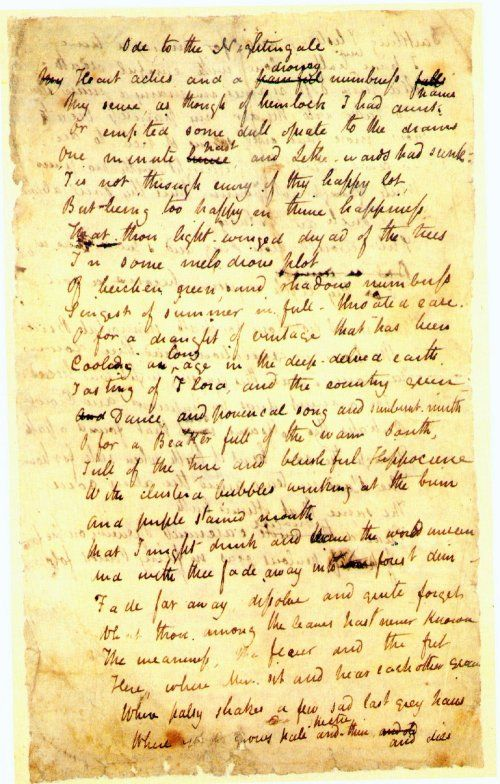

In [66]:
import os
import numpy as np
from PIL import Image
from IPython.display import display
from tkinter import Tk, filedialog

# Hide the Tkinter root window
root = Tk()
root.withdraw()
root.attributes("-topmost", True)

# Open file picker to select the scanned document
file_path = filedialog.askopenfilename(
    title="Select an image",
    filetypes=[
        ("Images", "*.png *.jpg *.jpeg *.bmp *.gif *.tiff *.webp"),
        ("All files", "*.*"),
    ],
)

if not file_path:
    raise ValueError("No image selected.")

# Create Uploads directory and set destination path
os.makedirs(UPLOADS_DIR, exist_ok=True)
filename = os.path.basename(file_path)
upload_path = os.path.join(UPLOADS_DIR, filename)

# Copy file to Uploads directory
with open(file_path, "rb") as src, open(upload_path, "wb") as dst:
    dst.write(src.read())

# Load file as numpy array
upload_file = Image.open(upload_path)
image: np.ndarray = np.array(upload_file)

print("Saved to:", upload_path)
print("Type:", type(image))
print("Shape:", image.shape)

display(upload_file)

#### 2. Apply K-Means clustering to the pixels of a BGR image.

The image is treated as a collection of independent colour samples — spatial relationships between pixels are deliberately ignored. This is valid for document segmentation because the three target regions (text, page, noise) are each characterised by a distinctive colour/brightness independent of where they appear on the page.


In [67]:
import cv2

# Returns tuple (H, W, C) where C is the number of BGR Channels.
h, w = image.shape[:2]

# Flatten the (H, W, 3) image to (H*W, 3) so each row is one pixel's BGR
# triple.  cv2.kmeans requires float32; uint8 would raise an error.
pixels: np.ndarray = image.reshape(-1, 3).astype(np.float32)

# Stopping criteria tuple: (type_flags, max_iterations, epsilon).
# TERM_CRITERIA_EPS  -> stop when centroid shift < epsilon.
# TERM_CRITERIA_MAX_ITER -> stop after max_iter iterations regardless.
MAX_ITER: int = 100
EPSILON: float = 1.0
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    MAX_ITER,
    EPSILON,
)

# cv2.kmeans signature: (data, K, bestLabels, criteria, attempts, flags[, centers])
# Returns: (compactness, labels, centers)
# We discard 'compactness' (inertia) as it is only used internally for selecting the best attempt.
_, label_flat, centers = cv2.kmeans(
    data=pixels,
    K=K,
    bestLabels=None,  # let OpenCV allocate the output label buffer
    criteria=criteria,
    attempts=10,  # run 10 independent initialisations
    flags=cv2.KMEANS_PP_CENTERS,
)

# label_flat has shape (H*W, 1); reshape back to the 2-D image grid.
labels: np.ndarray = label_flat.flatten().reshape(h, w)

print(f"[INFO]  K-Means complete  (k={K}, attempts=10)")
for i, c in enumerate(centers):
    # c is [B, G, R] because OpenCV uses BGR order.
    print(
        f"        Cluster {i}: centroid BGR = " f"({c[0]:.1f}, {c[1]:.1f}, {c[2]:.1f})"
    )

[INFO]  K-Means complete  (k=3, attempts=10)
        Cluster 0: centroid BGR = (248.3, 238.6, 182.2)
        Cluster 1: centroid BGR = (126.3, 90.8, 42.4)
        Cluster 2: centroid BGR = (223.4, 192.1, 126.2)


#### 3. Assign semantic roles

Map K-Means cluster indices to semantic roles using luminance ranking.


In [68]:
# Compute scalar luminance for each centroid.
# centers[:, 0] = B, centers[:, 1] = G, centers[:, 2] = R (BGR order).
luminance: np.ndarray = np.array(
    [0.2126 * c[2] + 0.7152 * c[1] + 0.0722 * c[0] for c in centers]
)

# np.argsort returns the indices that would sort luminance in ascending order,
# i.e. sorted_indices[0] is the darkest cluster index.
sorted_indices: np.ndarray = np.argsort(luminance)
role_to_index: dict[str, int] = {
    LABEL_FOREGROUND: int(sorted_indices[0]),  # darkest  -> ink/text
    LABEL_NOISE: int(sorted_indices[1]),  # middle   -> artefacts
    LABEL_BACKGROUND: int(sorted_indices[2]),  # brightest -> page
}

print("[INFO]  Cluster role assignment (by luminance):")
for role, idx in role_to_index.items():
    L = luminance[idx]
    c = centers[idx]
    print(
        f"        {role:12s} -> cluster {idx}  "
        f"(L={L:.1f}, BGR={c[0]:.0f},{c[1]:.0f},{c[2]:.0f})"
    )

[INFO]  Cluster role assignment (by luminance):
        Foreground   -> cluster 1  (L=83.1, BGR=126,91,42)
        Noise        -> cluster 2  (L=180.4, BGR=223,192,126)
        Background   -> cluster 0  (L=227.3, BGR=248,239,182)


#### 4a. Cluster visualisation (3-channel BGR)

Render a false-colour segmentation map from K-Means labels.


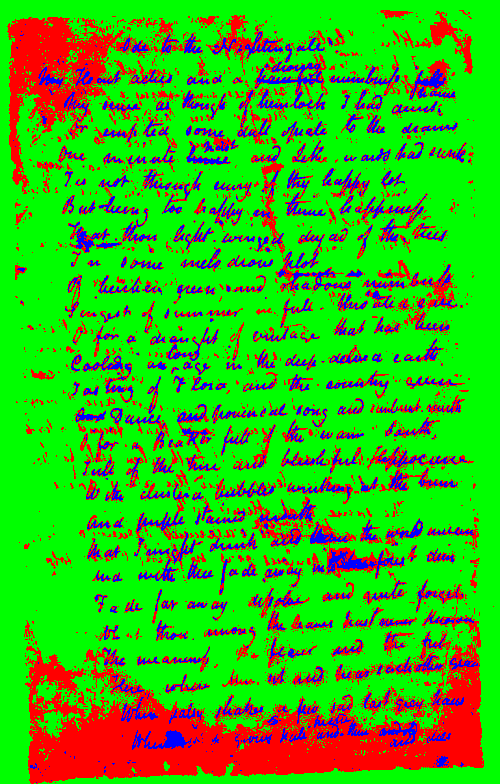

In [69]:
# Allocate an all-black canvas; we will paint each region in turn.
vis: np.ndarray = np.zeros((h, w, 3), dtype=np.uint8)

# Boolean index assignment - no Python loop over pixels needed.
# NumPy evaluates the boolean mask and assigns the colour vector in one
# vectorised operation.
vis[labels == role_to_index[LABEL_FOREGROUND]] = COLOR_FOREGROUND
vis[labels == role_to_index[LABEL_BACKGROUND]] = COLOR_BACKGROUND
vis[labels == role_to_index[LABEL_NOISE]] = COLOR_NOISE

display(Image.fromarray(vis))

#### 4b. Per-cluster transparent RGBA extractions

Extract one cluster from the image as an RGBA PNG with transparency.


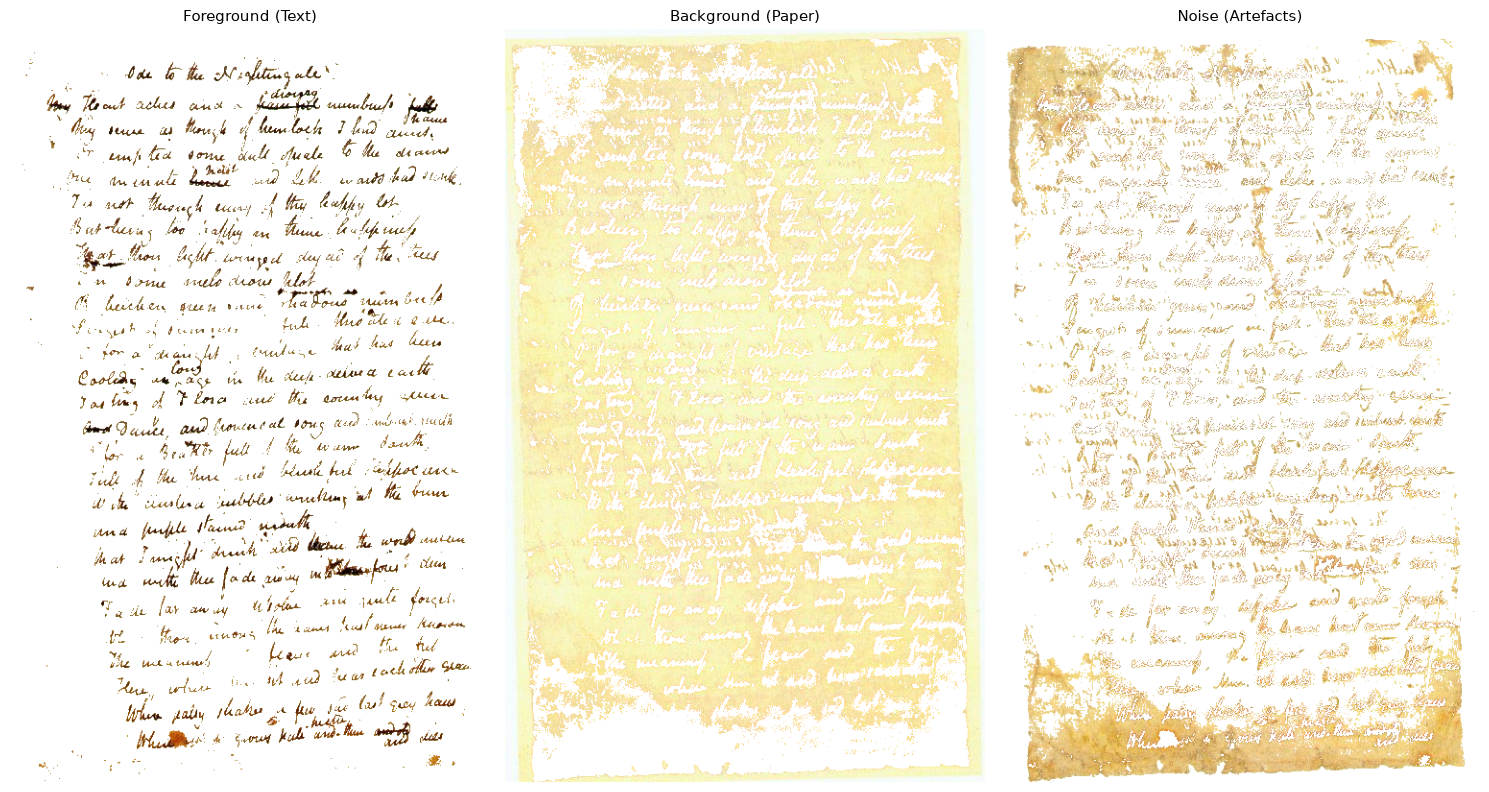

In [ ]:
def build_cluster_extraction(
    image: np.ndarray, labels: np.ndarray, cluster_index: int
) -> np.ndarray:
    # Add a fully-opaque alpha channel to every pixel.
    # Output shape: (H, W, 4) with channel order B, G, R, A.
    bgra: np.ndarray = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)

    # Build a boolean mask that is True wherever the pixel does NOT belong to
    # the requested cluster, then zero out their alpha values in one shot.
    outside_mask: np.ndarray = labels != cluster_index
    bgra[outside_mask, 3] = 0  # alpha = 0 -> fully transparent

    return bgra


fg_image: np.ndarray = build_cluster_extraction(
    image, labels, role_to_index[LABEL_FOREGROUND]
)
bg_image: np.ndarray = build_cluster_extraction(
    image, labels, role_to_index[LABEL_BACKGROUND]
)
noise_image: np.ndarray = build_cluster_extraction(
    image, labels, role_to_index[LABEL_NOISE]
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 7.84))

images = [fg_image, bg_image, noise_image]
titles = ["Foreground (Text)", "Background (Paper)", "Noise (Artefacts)"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()